In [1]:
%%bash

pip install datasets librosa soundfile torchaudio



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torchaudio
import torch
import numpy as np
from datasets import load_dataset
import warnings
import time
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
from util import calculate_wer, load_model

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

/Users/emm12/repos/whisper/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cpu


In [3]:
SAMPLE_LIMIT = 400
dataset = load_dataset("hf-audio/esb-datasets-test-only-sorted", "ami", split="test").select(range(3000, 3000 + SAMPLE_LIMIT))
audio_lengths = []
sample_paths = []
sample_sot = []

In [4]:
for i in range(SAMPLE_LIMIT):
    sample = dataset[i]
    audio_array = torch.tensor(sample['audio']['array']).float().to(device)  # Move to GPU
    sample_rate = sample['audio']['sampling_rate']
    local_audio_path = 'ami_data/' + sample['audio']['path']
    sot = sample['text']
    sample_paths.append(local_audio_path)
    sample_sot.append(sot)
    torchaudio.save(local_audio_path, audio_array.unsqueeze(0).cpu(), 16000)  # Move back to CPU before saving
    audio_length = len(sample['audio']['array']) / sample_rate
    print(f"Audio length: {audio_length} seconds")
    audio_lengths.append(audio_length)

Audio length: 3.69 seconds
Audio length: 3.69 seconds
Audio length: 3.69 seconds
Audio length: 3.69 seconds
Audio length: 3.68 seconds
Audio length: 3.68 seconds
Audio length: 3.68 seconds
Audio length: 3.68 seconds
Audio length: 3.68 seconds
Audio length: 3.68 seconds
Audio length: 3.68 seconds
Audio length: 3.68 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.67 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.66 seconds
Audio length: 3.6500625 seconds
Audio length: 3.65 seconds
Audio length: 3.65 seco

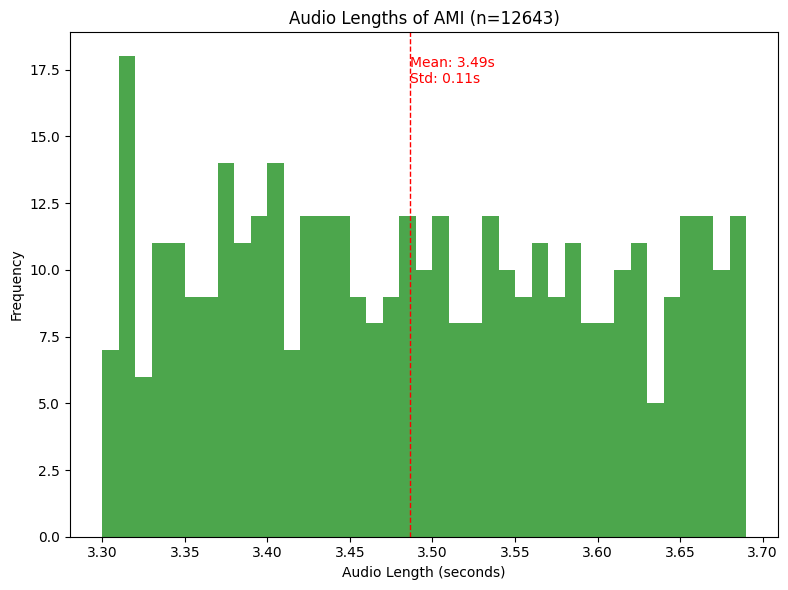

In [5]:
# Create a new figure for audio length distribution
plt.figure(figsize=(8, 6))
audio_bins = np.linspace(min(audio_lengths), max(audio_lengths), 40)
plt.hist(audio_lengths, bins=audio_bins, alpha=0.7, color='green')
plt.axvline(np.mean(audio_lengths), color='red', linestyle='dashed', linewidth=1)
plt.text(np.mean(audio_lengths), plt.ylim()[1]*0.9, 
         f'Mean: {np.mean(audio_lengths):.2f}s\nStd: {np.std(audio_lengths):.2f}s', 
         color='red')
plt.xlabel('Audio Length (seconds)')
plt.ylabel('Frequency')
plt.title('Audio Lengths of AMI (n=12643)')

plt.tight_layout()
plt.show()

In [6]:
model = load_model(ff=True)
model_original = load_model(ff=False)

In [ ]:
import tqdm

device = 'cpu'
wers = []
wers_original = []
times = []
times_original = []

with tqdm.tqdm(total=SAMPLE_LIMIT) as pbar:
    for i in range(SAMPLE_LIMIT):
        path = 'ami_data/' + dataset[i]['audio']['path']
        t = time.time()
        hyp = model.transcribe(path, verbose=False)['text']
        t = time.time() - t
        times.append(t)
        t = time.time()
        hyp_original = model_original.transcribe(path, verbose=False)['text']
        t = time.time() - t
        times_original.append(t)
        
        ref = dataset[i]['text']
        wer = calculate_wer(hyp, ref)
        wer_original = calculate_wer(hyp_original, ref)
        wers.append(wer)
        wers_original.append(wer_original)
        
        pbar.update(1)  # Update progress bar after each iteration

  3%|▎         | 13/400 [00:07<03:28,  1.86it/s]


KeyboardInterrupt: 

In [ ]:
num_bins = 50

# Calculate statistics
wer_mean = np.mean(wers)
wer_std = np.std(wers)
wer_original_mean = np.mean(wers_original)
wer_original_std = np.std(wers_original)

time_mean = np.mean(times)
time_std = np.std(times)
time_original_mean = np.mean(times_original)
time_original_std = np.std(times_original)

# Create bins using linspace
wer_bins = np.linspace(min(min(wers), min(wers_original)), max(max(wers), max(wers_original)), num_bins)
time_bins = np.linspace(min(min(times), min(times_original)), max(max(times), max(times_original)), num_bins)

# Plotting the distribution of WER
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(wers, bins=wer_bins, alpha=0.5, label='WER with cut')
plt.hist(wers_original, bins=wer_bins, alpha=0.5, label='WER original')
plt.axvline(wer_mean, color='blue', linestyle='dashed', linewidth=1)
plt.axvline(wer_original_mean, color='orange', linestyle='dashed', linewidth=1)
plt.text(wer_mean, plt.ylim()[1]*0.9, f'Mean: {wer_mean:.2f}\nStd: {wer_std:.2f}', color='blue')
plt.text(wer_original_mean, plt.ylim()[1]*0.8, f'Mean: {wer_original_mean:.2f}\nStd: {wer_original_std:.2f}', color='orange')
plt.xlabel('WER')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.title(f'WER, n={SAMPLE_LIMIT}')

# Plotting the distribution of time
plt.subplot(1, 2, 2)
plt.hist(times, bins=time_bins, alpha=0.5, label='time with cut')
plt.hist(times_original, bins=time_bins, alpha=0.5, label='time original')
plt.axvline(time_mean, color='blue', linestyle='dashed', linewidth=1)
plt.axvline(time_original_mean, color='orange', linestyle='dashed', linewidth=1)
plt.text(time_mean, plt.ylim()[1]*0.9, f'Mean: {time_mean:.2f}\nStd: {time_std:.2f}', color='blue')
plt.text(time_original_mean, plt.ylim()[1]*0.8, f'Mean: {time_original_mean:.2f}\nStd: {time_original_std:.2f}', color='orange')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.title(f'Time taken, n={SAMPLE_LIMIT}')

plt.tight_layout()
plt.show()


In [ ]:
# Calculate statistics
wer_mean = np.mean(wers)
wer_std = np.std(wers)
wer_original_mean = np.mean(wers_original)
wer_original_std = np.std(wers_original)

time_mean = np.mean(times)
time_std = np.std(times)
time_original_mean = np.mean(times_original)
time_original_std = np.std(times_original)

# Plotting WER vs. inference time
plt.figure(figsize=(12, 6))

plt.scatter(times, wers, alpha=0.5, label='WER with cut')
plt.scatter(times_original, wers_original, alpha=0.5, label='WER original')
plt.axhline(wer_mean, color='blue', linestyle='dashed', linewidth=1)
plt.axhline(wer_original_mean, color='orange', linestyle='dashed', linewidth=1)
plt.axvline(time_mean, color='blue', linestyle='dashed', linewidth=1)
plt.axvline(time_original_mean, color='orange', linestyle='dashed', linewidth=1)
plt.text(time_mean, plt.ylim()[1]*0.9, f'Mean Time: {time_mean:.2f}\nStd: {time_std:.2f}', color='blue')
plt.text(time_original_mean, plt.ylim()[1]*0.8, f'Mean Time: {time_original_mean:.2f}\nStd: {time_original_std:.2f}', color='orange')
plt.text(plt.xlim()[1]*0.9, wer_mean, f'Mean WER: {wer_mean:.2f}\nStd: {wer_std:.2f}', color='blue', verticalalignment='center')
plt.text(plt.xlim()[1]*0.9, wer_original_mean, f'Mean WER: {wer_original_mean:.2f}\nStd: {wer_original_std:.2f}', color='orange', verticalalignment='center')

plt.xlabel('Inference Time (s)')
plt.ylabel('WER')
plt.legend(loc='upper right')
plt.title('WER vs. Inference Time')

plt.tight_layout()
plt.show()


In [ ]:
wers = []
for path, sot in zip(sample_paths, sample_sot):
    wers.append(calculate_wer(model.transcribe(path, verbose=True)['text'], sot))
    
plt.hist(wers)

In [ ]:
tests = [f'out{i:03d}' for i in range(50)]
audio_paths_5 = [f"test_data/5s/{t}.wav" for t in tests]
transcript_paths_5 = [f"test_transcripts_before/5s/{t}.txt" for t in tests]
audio_paths_10 = [f"test_data/10s/{t}.wav" for t in tests]
transcript_paths_10 = [f"test_transcripts_before/10s/{t}.txt" for t in tests]
audio_paths_15 = [f"test_data/15s/{t}.wav" for t in tests]
transcript_paths_15 = [f"test_transcripts_before/15s/{t}.txt" for t in tests]
audio_paths_20 = [f"test_data/20s/{t}.wav" for t in tests]
transcript_paths_20 = [f"test_transcripts_before/20s/{t}.txt" for t in tests]
audio_paths_25 = [f"test_data/25s/{t}.wav" for t in tests]
transcript_paths_25 = [f"test_transcripts_before/25s/{t}.txt" for t in tests]
audio_paths_30 = [f"test_data/30s/{t}.wav" for t in tests]
transcript_paths_30 = [f"test_transcripts_before/30s/{t}.txt" for t in tests]


In [ ]:
def eval(model, audio_paths, transcript_paths):
    wer = []
    for audio_path, transcript_path in zip(audio_paths, transcript_paths):
        transcript = model.transcribe(audio_path)['text']
        with open(transcript_path) as f:
            true_transcript = f.read()
        wer.append(calculate_wer(true_transcript, transcript))
        
    return wer
  
wer_5  = eval(model, audio_paths_5, transcript_paths_5)
wer_10 = eval(model, audio_paths_10, transcript_paths_10)
wer_15 = eval(model, audio_paths_15, transcript_paths_15)
wer_30 = eval(model, audio_paths_30, transcript_paths_30)

In [ ]:
data = {5: wer_5, 10: wer_10, 15: wer_15, 30: wer_30}

plt.figure(figsize=(12, 8))

for snippet_time, wer in data.items():
  plt.hist(wer, bins=20, alpha=0.5, label=f'{snippet_time}s')

plt.xlabel('WER')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.title('Distribution of Word Error Rates by Snippet Time')
plt.show()

In [ ]:
fname='features_before_pruning_2b7b38e4-24b8-4ddf-9bf3-710bd2f07223.txt'
features = np.loadtxt(fname, delimiter=',')

print(features.shape)
assert features.shape == (1500, 384)


In [ ]:
print(np.linalg.norm(features, axis=1))
print(features[-1][:10])
print(features[-2][:10])

In [ ]:
def visualize_with_pca_and_clustering(features, n_clusters=2):
    
    pca = PCA(n_components=2)
    features_2d = pca.fit_transform(features)
    
    plt.style.use('seaborn-v0_8')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    scatter = ax1.scatter(features_2d[:, 0], features_2d[:, 1], 
                         c=np.linalg.norm(features, axis=1),  # color by magnitude
                         cmap='viridis', alpha=0.6)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax1.set_title('PCA of Audio Features\nColored by Feature Magnitude')
    
    plt.colorbar(scatter, ax=ax1, label='Feature Magnitude')
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(features_2d)
    scatter2 = ax2.scatter(features_2d[:, 0], features_2d[:, 1], 
                          c=clusters, cmap='Set3', alpha=0.6)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax2.set_title('Clustered PCA of Audio Features')

    ax2.legend()
    
    total_var = pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]
    fig.suptitle(f'Raw features before pruning (Total Explained Variance: {total_var:.1%})', 
                 fontsize=14, y=1.05)
    
    cluster_sizes = np.bincount(clusters)
    feature_magnitudes = np.linalg.norm(features, axis=1)
    cluster_avg_magnitudes = [np.mean(feature_magnitudes[clusters == i]) 
                            for i in range(n_clusters)]
    
    for i in range(n_clusters):
        print(f"cluster {i}:")
        print(f"  size: {cluster_sizes[i]} tokens")
        print(f"  average feature magnitude: {cluster_avg_magnitudes[i]:.3f}")
    
    plt.tight_layout()
    plt.show()
    
    return pca, kmeans

In [ ]:
# visualize_with_pca(features)
pca, kmeans = visualize_with_pca_and_clustering(features, n_clusters=2)

In [ ]:
def visualize_sequence_distribution(features, kmeans_labels=None):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), height_ratios=[3, 1])
    
    feature_magnitudes = np.linalg.norm(features, axis=1)
    # scatter = ax1.scatter(range(len(features)), 
    #                      feature_magnitudes,
    #                      c=feature_magnitudes,
    #                      cmap='viridis',
    #                      alpha=0.6)
    # ax1.set_title('Feature Magnitudes Along Sequence')
    # ax1.set_xlabel('Sample Index')
    # ax1.set_ylabel('Feature Magnitude')
    # plt.colorbar(scatter, ax=ax1, label='Magnitude')
    
    # rolling average of feature magnitudes
    window = 50
    rolling_avg = np.convolve(feature_magnitudes, 
                             np.ones(window)/window, 
                             mode='valid')
    ax1.plot(range(window-1, len(features)), 
             rolling_avg, 
             'r-', 
             label=f'Rolling Average (window={window})',
             alpha=0.8)
    ax1.legend()
    
    # cluster distribution in original sequence
    if kmeans_labels is not None:
        unique_clusters = np.unique(kmeans_labels)
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_clusters)))
      
        ax2.scatter(range(len(features)), 
                   [0] * len(features),
                   c=kmeans_labels,
                   cmap='Set3',
                   s=100,
                   marker='s')
        ax2.set_title('Cluster Distribution Along Sequence')
        ax2.set_xlabel('Sample Index')
        ax2.set_yticks([])
        
        cluster_counts = np.bincount(kmeans_labels)
        cluster_percentages = cluster_counts / len(kmeans_labels) * 100
        cluster_info = [f'Cluster {i}: {count} samples ({percentage:.1f}%)' 
                       for i, (count, percentage) in enumerate(zip(cluster_counts, cluster_percentages))]
        ax2.text(1.02, 0.5, '\n'.join(cluster_info), 
                transform=ax2.transAxes,
                verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Mean magnitude: {np.mean(feature_magnitudes):.3f}")
    print(f"Std magnitude: {np.std(feature_magnitudes):.3f}")
    print(f"Min magnitude: {np.min(feature_magnitudes):.3f}")
    print(f"Max magnitude: {np.max(feature_magnitudes):.3f}")
    
    # Calculate potential pruning thresholds
    percentiles = [25, 50, 75]
    thresholds = np.percentile(feature_magnitudes, percentiles)
    print("\nPotential pruning thresholds:")
    for p, t in zip(percentiles, thresholds):
        count = np.sum(feature_magnitudes < t)
        print(f"{p}th percentile: {t:.3f} (would prune {count} tokens, {count/len(features)*100:.1f}%)")

pca, kmeans = visualize_with_pca_and_clustering(features)
visualize_sequence_distribution(features, kmeans.labels_)

In [ ]:
def eval(model, audio_paths, transcript_paths):
  WER = []
  TIME = []

  for audio_path, transcript_path in zip(audio_paths, transcript_paths):
      hypothesis, elapsed_time = transcribe(model, audio_path)
      with open(transcript_path, "r") as f:
          reference = f.read()

      TIME.append(elapsed_time)

      wer = calculate_wer(hypothesis, reference)
      WER.append(wer)
  return WER, TIME

In [ ]:
def test(cut_start, cut_end, audio_paths, transcript_paths):
    model = load_model(ff=True, cut_region=(cut_start, cut_end))
    WER, TIME = eval(model, audio_paths, transcript_paths)
    return WER, TIME

def search(audio_paths, transcript_paths):
    WERs = []
    TIMEs = []
    CUTs = []
    for cut_start in range(0, 1000, 50):
        cut_end = cut_start + 500
        WER, TIME = test(cut_start, cut_end, audio_paths, transcript_paths)
        WER = sum(WER) / len(WER)
        TIME = sum(TIME) / len(TIME)
        WERs.append(WER)
        TIMEs.append(TIME)
        CUTs.append((cut_start, cut_end))
    return CUTs, WERs, TIMEs

def plot(CUTs, WERs, TIMEs, title):
    plt.figure(figsize=(10, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot([c[0] for c in CUTs], WERs, marker='o')
    plt.title(title + " WER")
    plt.xlabel("Cut start position")
    plt.ylabel("WER")
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    plt.subplot(2, 1, 2)
    plt.plot([c[0] for c in CUTs], TIMEs, marker='o')
    plt.title(title + " Time")
    plt.xlabel("Cut start position")
    plt.ylabel("Time")
    plt.xticks(rotation=45)
    
    # Add spacing between subplots
    plt.tight_layout()
    plt.show()

In [ ]:
CUTs_5, WERs_5, TIMEs_5 = search(audio_paths_5, transcript_paths_5)

In [ ]:
CUTs_10, WERs_10, TIMEs_10 = search(audio_paths_10, transcript_paths_10)

In [ ]:
CUTs_15, WERs_15, TIMEs_15 = search(audio_paths_15, transcript_paths_15)


In [ ]:
CUTs_20, WERs_20, TIMEs_20 = search(audio_paths_20, transcript_paths_20)


In [ ]:
CUTs_25, WERs_25, TIMEs_25 = search(audio_paths_25, transcript_paths_25)


In [ ]:
CUTs_30, WERs_30, TIMEs_30 = search(audio_paths_30, transcript_paths_30)

In [ ]:
plot(CUTs_5, WERs_5, TIMEs_5, "5s")

In [ ]:
plot(CUTs_10, WERs_10, TIMEs_10, "10s")

In [ ]:
plot(CUTs_15, WERs_15, TIMEs_15, "15s")

In [ ]:
plot(CUTs_20, WERs_20, TIMEs_20, "20s")

In [ ]:
plot(CUTs_25, WERs_25, TIMEs_25)

In [ ]:
plot(CUTs_30, WERs_30, TIMEs_30)

In [ ]:
model_for_5s = load_model(ff=True, cut_region=(750,1400))
original_model = load_model(ff=False)

In [ ]:
eval_5s = eval(model_for_5s, audio_paths_5, transcript_paths_5)

In [ ]:

eval_original = eval(original_model, audio_paths_5, transcript_paths_5)

In [ ]:
WER_5s, TIME_5s = eval_5s
WER_original, TIME_original = eval_original


In [ ]:
def plot_distributions(*lists, labels=None, bins=50):
  plt.figure(figsize=(12, 8))
  
  for i, lst in enumerate(lists):
    label = labels[i] if labels else f'List {i+1}'
    plt.hist(lst, bins=bins, alpha=0.5, label=label)
  
  plt.xlabel('Value')
  plt.ylabel('Frequency')
  plt.legend(loc='upper right')
  plt.title('Distribution of Values')
  plt.show()

# Example usage
plot_distributions(WER_5s, WER_original, labels=['WER 5s', 'WER Original'])
plot_distributions(TIME_5s, TIME_original, labels=['Time 5s', 'Time Original'])
